In [1]:
import tensorflow as tf

import numpy as np
import matplotlib.pyplot as plt

from src.green_gecko_model import CAModel, make_seed
from src.fourier import find_peaks, plot_fourier

# Calculating the Fourier spectra
### Load model

In [2]:
#@title Cellular Automata Parameters
CHANNEL_N = 16        # Number of CA state channels
TARGET_PADDING = 16   # Number of pixels used to pad the target image border
TARGET_SIZE = 40
CELL_FIRE_RATE = 1. #0.5

# My own defined things
size = TARGET_SIZE + TARGET_PADDING * 2
x_start, y_start = TARGET_PADDING, TARGET_PADDING # size//2, size//2 # 
x_end, y_end =  TARGET_PADDING+TARGET_SIZE, TARGET_PADDING+TARGET_SIZE #size//2+1, size//2+1 #

In [3]:
model = CAModel(channel_n=CHANNEL_N, fire_rate=CELL_FIRE_RATE)
model.load_weights("model/plain_salamander/big_fire_rate1_nr3/8000.weights.h5")
None

2026-04-12 19:32:12.427583: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Pro
2026-04-12 19:32:12.427610: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-04-12 19:32:12.427620: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-04-12 19:32:12.427639: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-04-12 19:32:12.427651: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
2026-04-12 19:32:12.837970: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


### Run model for quite a while
To get burn-in phase (2000 steps), and the spectrum (8000)

In [4]:
seed = make_seed(TARGET_SIZE+TARGET_PADDING*2, n=1, channel_n=CHANNEL_N)
x = tf.convert_to_tensor(seed)

states = [tf.identity(x).numpy()]

for iter in range(10000):
    x = model(x)
    states.append(tf.identity(x).numpy())

states_np = np.stack(states)[:,:,x_start:x_end,y_start:y_end] 
print(states_np.shape)

(10001, 1, 40, 40, 16)


In [5]:
flattened_attractor_states = states_np.reshape(states_np.shape[0], -1)

### Get the spectrum
It's first plotted without a log scaled y-axis. This is helpful to me to know how many peaks we care about. Then plotted with log-scaled y-axis, as is convention.

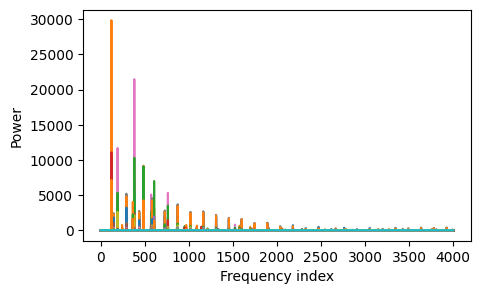

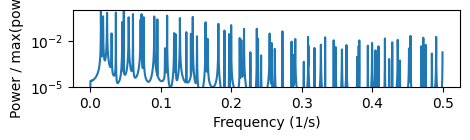

In [6]:
raw_attractor = flattened_attractor_states[2000:]

power, freqs = plot_fourier(raw_attractor, dt=1.0, filename="version3", reduce_x_by=None, figure_size=(5,1))

Determine how many peaks we should care about. The cut-off point is a bit arbitrary, of course, but helps preserve the lowest frequency peaks, which we care the most about. 

In [7]:
freqs[power > 0.01].shape

(84,)

In [13]:
print(freqs[find_peaks(power, k=84)])

[0.04761905 0.01512311 0.03637045 0.02387202 0.06061742 0.07274091
 0.10911136 0.01812273 0.09086364 0.14548181 0.07574053 0.05449319
 0.1272341  0.0952381  0.07149106 0.04549431 0.16360455 0.18185227
 0.199975   0.23634546 0.21822272 0.19047619 0.27271591 0.13635796
 0.11898513 0.03024622 0.25459318 0.14285714 0.19697538 0.12123485
 0.45456818 0.15148106 0.30908636 0.49093863 0.33333333 0.47269091
 0.21209849 0.41819773 0.23809524 0.16660417 0.29096363 0.43632046
 0.21434821 0.34545682 0.38182727 0.28571429 0.42857143 0.39995001
 0.2575928  0.32733408 0.47619048 0.36357955 0.39395076 0.30946132
 0.38095238 0.46969129 0.40907387 0.34845644 0.31821022 0.10611174
 0.45231846 0.26184227 0.35720535 0.40469941 0.2272216  0.4848144
 0.28783902 0.24246969 0.37882765 0.42419698 0.43944507 0.30308711
 0.06361705 0.00299963 0.03937008 0.19085114 0.19397575 0.26971629]


### Eliminate harmonics

In [14]:
f = freqs[find_peaks(power, k=84)]

def is_harmonics(f1, f2, tol=0.0002):

    for i in range(2, 20):
        if abs(f1*float(i) - f2) < tol:
            return True
        
    return False

frequncy_families = []

f_sorted = sorted(f)

while len(f_sorted) > 0:
    f1 = f_sorted.pop(0)
    family = [f1]
    for f2 in f_sorted:
        if is_harmonics(f1, f2):
            family.append(f2)
            f_sorted.remove(f2)
    frequncy_families.append(family)


Now we have some candidate base frequencies

In [15]:
bases = [family[0] for family in frequncy_families]
bases, len(bases)

([0.002999625046869141,
  0.018122734658167727,
  0.03024621922259717,
  0.03937007874015748,
  0.04549431321084864,
  0.047619047619047616,
  0.06361704786901637,
  0.07149106361704786,
  0.07274090738657667,
  0.0757405324334458,
  0.10611173603299587,
  0.10911136107986501,
  0.1189851268591426,
  0.12123484564429444,
  0.16360454943132108,
  0.1666041744781902,
  0.1939757530308711,
  0.19997500312460942,
  0.2575928008998875,
  0.26184226971628544,
  0.2697162854643169,
  0.2727159105111861,
  0.28783902012248463,
  0.3090863642044744,
  0.30946131733533305,
  0.3454568178977627,
  0.3484564429446319,
  0.3572053493313335,
  0.39395075615548053,
  0.4046994125734283,
  0.4090738657667791,
  0.4181977252843394,
  0.4241969753780777,
  0.43944506936632916,
  0.4523184601924759,
  0.46969128858892634,
  0.47269091363579546],
 37)

### Eliminate linear combinations, if any

In [16]:
def is_linear_combination(f1, f2, f3, tol=0.0002):
    for i in range(1, 60):
        for j in range(1, 60):
            if abs(f1*float(i) + f2*float(j) - f3) < tol:
                print(f"{f1}*{i} + {f2}*{j} = {f3}")
                return True
    return False
            
has_been_linear_combo = []
has_linear_combo = {freq: False for freq in bases}

for f1 in bases:
    for f2 in bases:
        if f1 == f2:
            continue
        for f3 in bases:
            if f3 in has_been_linear_combo:
                continue
            if is_linear_combination(f1, f2, f3):
                has_linear_combo[f3] = True
                has_been_linear_combo.append(f3)

print(has_linear_combo)



0.002999625046869141*4 + 0.018122734658167727*1 = 0.03024621922259717
0.002999625046869141*1 + 0.018122734658167727*2 = 0.03937007874015748
0.002999625046869141*39 + 0.018122734658167727*8 = 0.26184226971628544
0.002999625046869141*2 + 0.018122734658167727*22 = 0.4046994125734283
0.002999625046869141*30 + 0.018122734658167727*20 = 0.4523184601924759
0.002999625046869141*1 + 0.03024621922259717*2 = 0.06361704786901637
0.002999625046869141*2 + 0.03937007874015748*1 = 0.04549431321084864
0.002999625046869141*1 + 0.03937007874015748*3 = 0.12123484564429444
0.002999625046869141*2 + 0.03937007874015748*4 = 0.16360454943132108
0.002999625046869141*3 + 0.03937007874015748*4 = 0.1666041744781902
0.002999625046869141*1 + 0.03937007874015748*5 = 0.19997500312460942
0.002999625046869141*1 + 0.03937007874015748*9 = 0.3572053493313335
0.002999625046869141*5 + 0.04549431321084864*2 = 0.10611173603299587
0.002999625046869141*6 + 0.04549431321084864*2 = 0.10911136107986501
0.002999625046869141*4 + 0.04

And whatever remains should be our base frequencies

In [18]:
for freq in has_linear_combo:
    if not has_linear_combo[freq]:
        print(freq)

0.002999625046869141
0.018122734658167727
0.047619047619047616
